In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 150


## The obvious suspects

We are not trying to prove the obvious. We are testing whether the most famous names really sit at the center of the network by more than one definition of centrality.

The next step is to compare how characters rank on in-degree, out-degree, and undirected degree. This gives us the "usual suspects" before we look for the weird cases that do not fit the expectation.


## The first question: who is the most connected?

We begin with undirected degree because it is the simplest way to answer, "how many distinct neighbors does this character have?"

Spider-Man may dominate this view — that is not a surprise. The more interesting question is whether the same characters dominate every notion of importance, or whether different kinds of importance point to different superheroes.


## Being talked about vs doing the talking

In a directed network, there is an important difference between being referenced by many others and referencing many others in turn.

- in-degree = how many pages point to this superhero
- out-degree = how many pages this superhero points to
- undirected degree = how many distinct neighbors in total

These are related, but they are not the same thing.


## Not all Marvel hubs behave the same way

The next question is not "who is central?" but "what is the pattern of centrality?" Some characters receive many links. Some send many links. Some do both. Others barely participate in this network at all.

We create a simple 'link personality' for each character by looking at how much it receives versus emits.


## Define network archetypes

The data suggest that not all hub-like characters are alike. We can classify them by how much they receive versus emit.

To keep the rules transparent, we use percentile-based thresholds rather than arbitrary fixed degree cutoffs. A character is extreme only if it sits in the top or bottom portion of the observed distribution.

- Celebrities: high in-degree, relatively low out-degree
- Connectors: high out-degree relative to in-degree
- Socialites: high in-degree and high out-degree
- Outsiders: very few or zero links inside this network


## Hidden celebrities

Some characters become famous in the network not because they send out many links, but because many other pages point toward them.

These are the characters who receive attention without necessarily being active connectors themselves.


## The forgotten heroes

A network is not only made of famous hubs. It also contains characters that are peripheral to this 303-character Marvel universe.

Here we focus on the edge: isolates, degree-1 nodes, and members of tiny components outside the giant network.


## The final Marvel character map

This is the main visual summary of the notebook. We use the full network but keep only a small subset of labels. The plot emphasizes that there are different kinds of importance in the same network.

- High in-degree = attention from many other pages
- High out-degree = active linking behavior
- High total degree = strong participation in both directions
- Near origin = minimal visibility inside this superhero subgraph


## So who is the center of the Marvel Wikipedia universe?

We started with a simple assumption: famous superheroes should sit at the center of the Marvel Wikipedia network. That turns out to be only partly true.

Some characters dominate because many other pages point toward them. Others dominate because they point out to many pages. Some combine both behaviors. Some are peripheral, and a few are effectively absent from this 303-character network.

The key point is that there is no single definition of importance. A character can be central in one sense and peripheral in another. A Wikipedia hyperlink network is not a map of fictional friendship or canonical importance; it is a map of how the wiki itself organizes attention.

In other words, the center of the Marvel universe depends on what kind of center we mean.


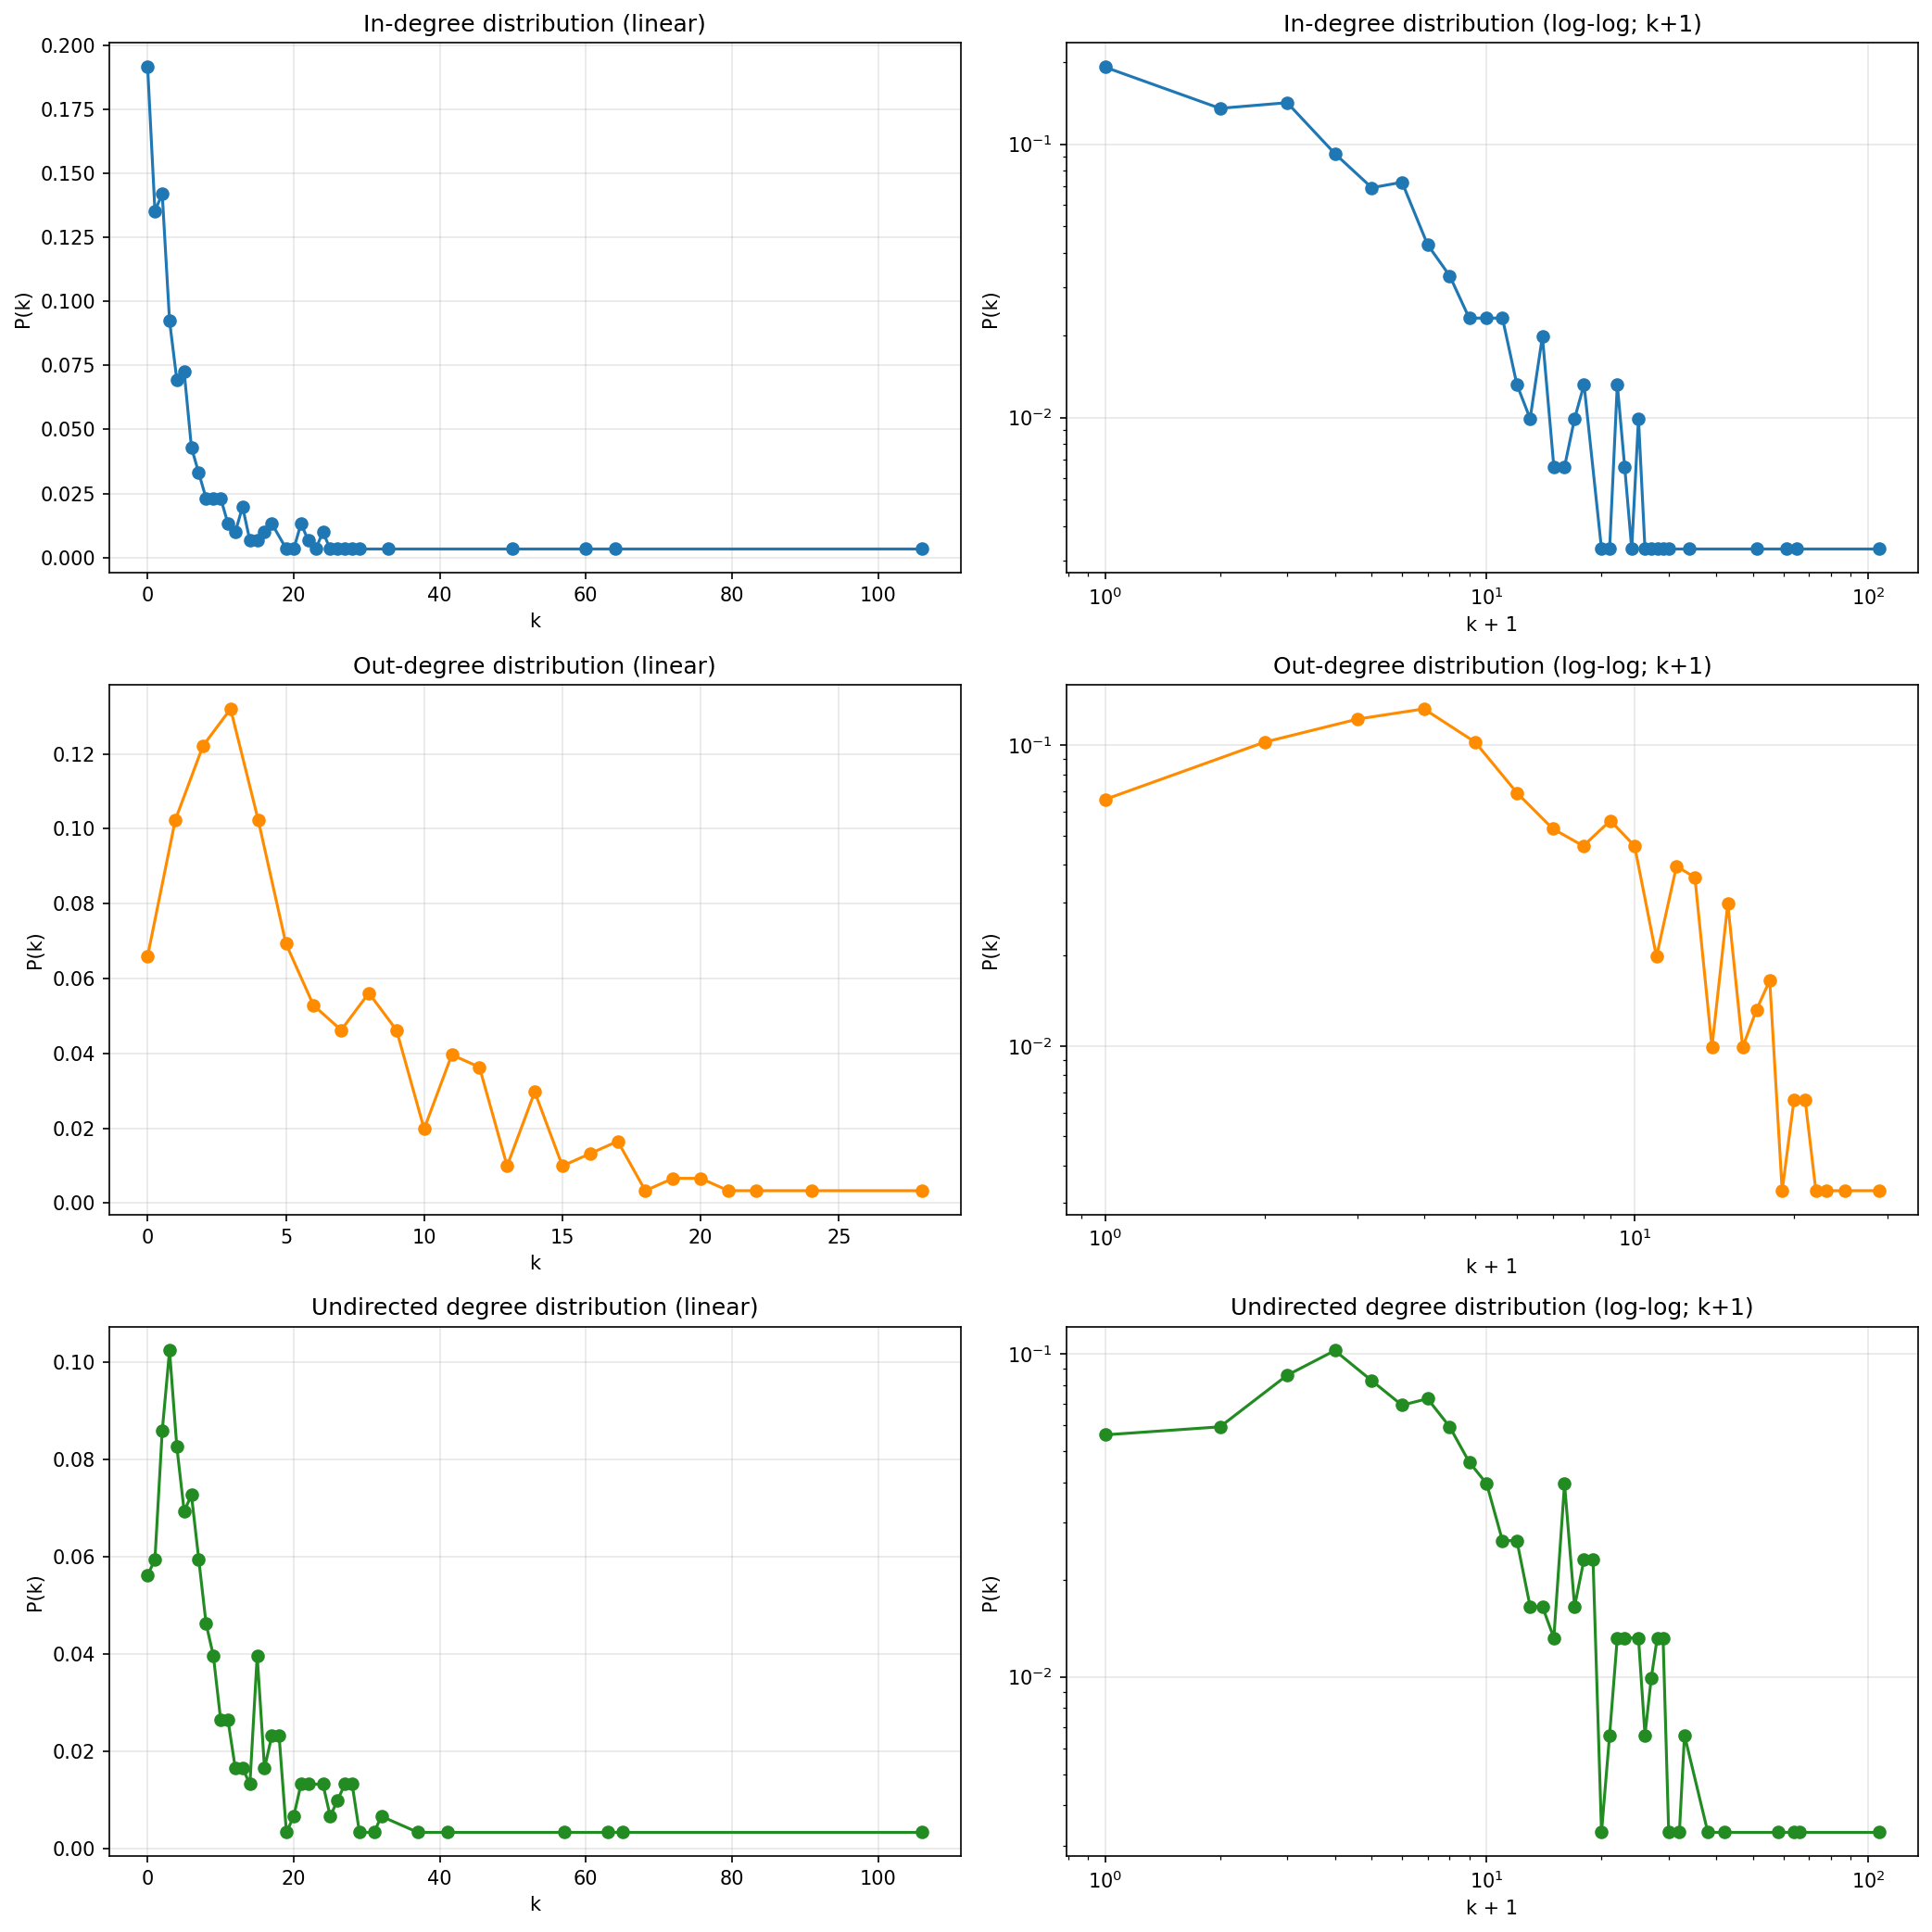

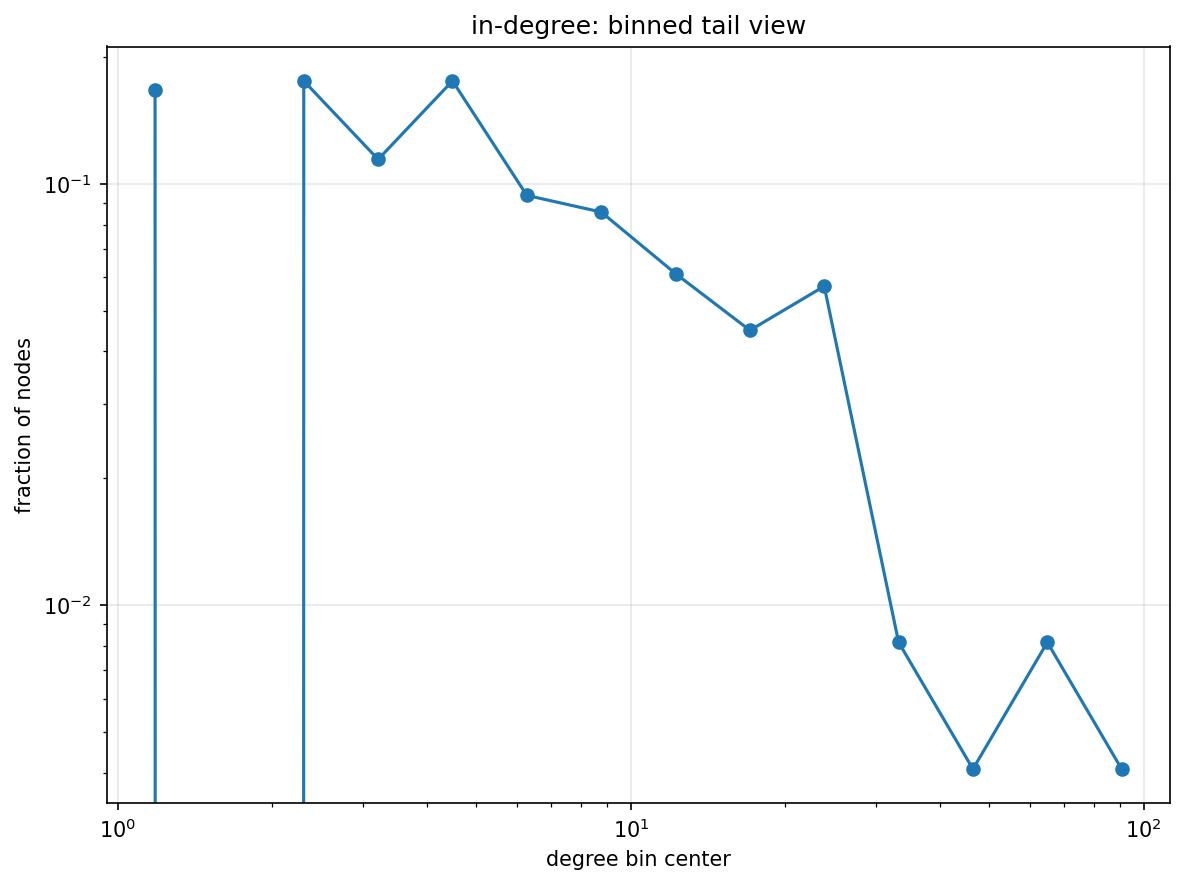

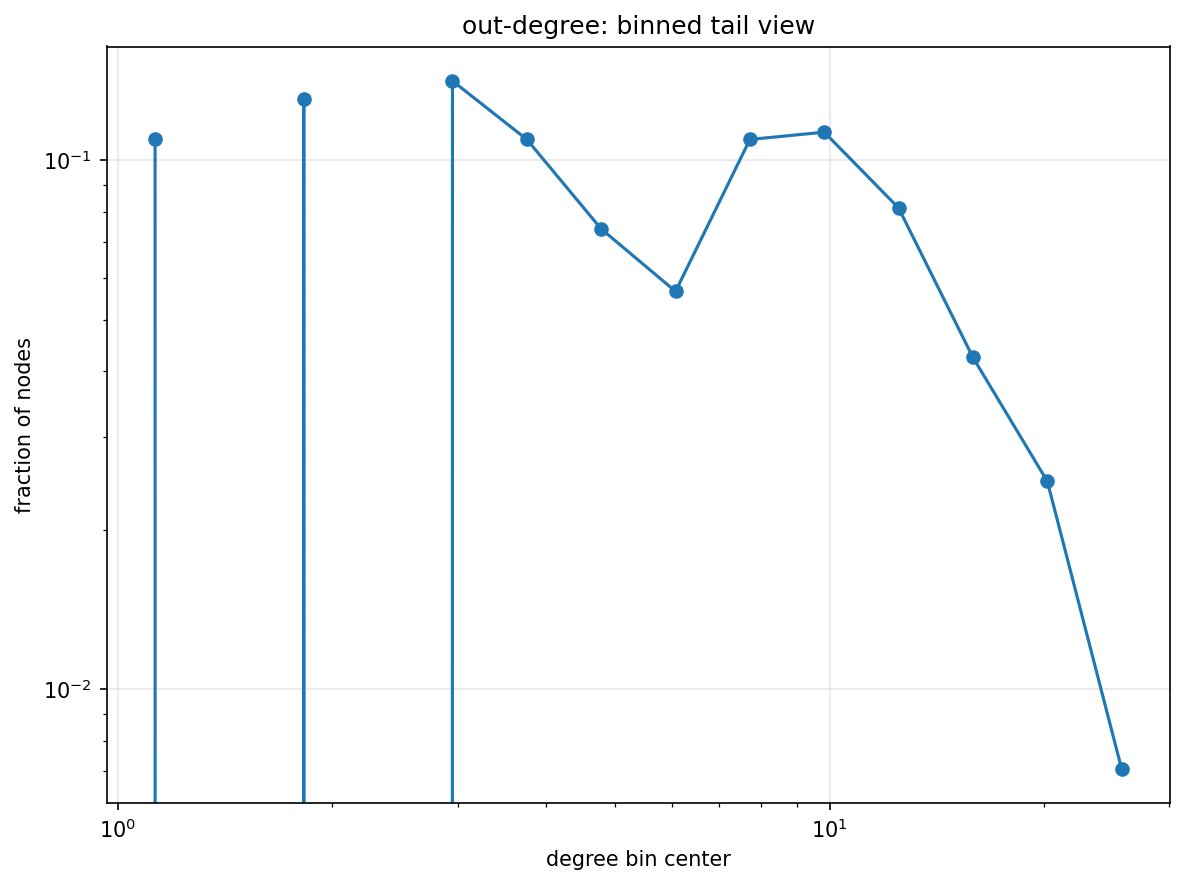

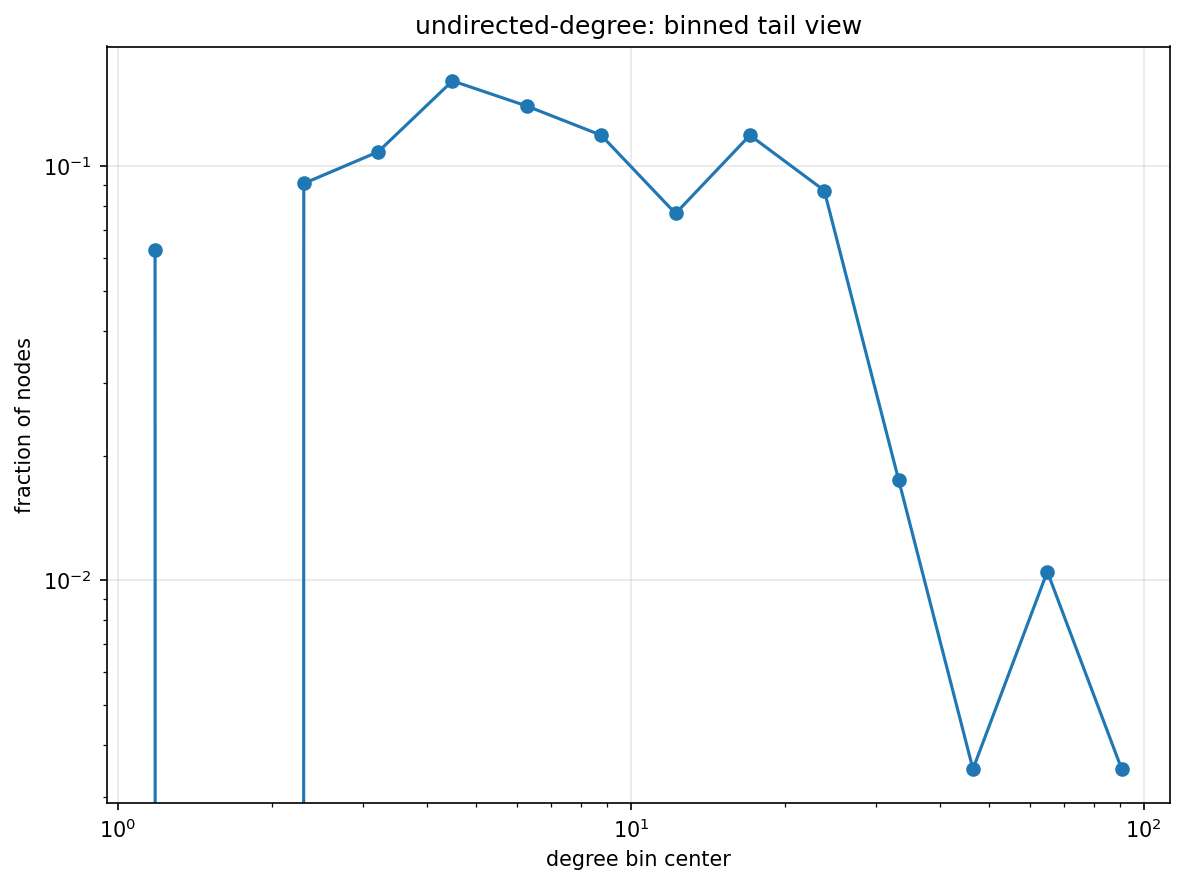

Appendix plots saved to outputs/


In [12]:
# Degree distributions for the appendix
# We use the fraction of nodes P(k) to keep the comparison transparent.

def degree_distribution(degrees):
    counts = Counter(degrees)
    total = sum(counts.values())
    dist = pd.DataFrame({'k': sorted(counts.keys()), 'P_k': [counts[k] / total for k in sorted(counts.keys())]})
    return dist

in_deg = [G.in_degree(n) for n in G.nodes()]
out_deg = [G.out_degree(n) for n in G.nodes()]
und_deg = [G_u.degree(n) for n in G.nodes()]

in_dist = degree_distribution(in_deg)
out_dist = degree_distribution(out_deg)
und_dist = degree_distribution(und_deg)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# linear plots
axes[0, 0].plot(in_dist['k'], in_dist['P_k'], marker='o')
axes[0, 0].set_title('In-degree distribution (linear)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('P(k)')
axes[0, 0].grid(alpha=0.3)

axes[1, 0].plot(out_dist['k'], out_dist['P_k'], marker='o', color='darkorange')
axes[1, 0].set_title('Out-degree distribution (linear)')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('P(k)')
axes[1, 0].grid(alpha=0.3)

axes[2, 0].plot(und_dist['k'], und_dist['P_k'], marker='o', color='forestgreen')
axes[2, 0].set_title('Undirected degree distribution (linear)')
axes[2, 0].set_xlabel('k')
axes[2, 0].set_ylabel('P(k)')
axes[2, 0].grid(alpha=0.3)

# log-log plots, handling zero degrees explicitly by plotting k+1 for the x-axis
in_dist_log = degree_distribution([d + 1 for d in in_deg])
out_dist_log = degree_distribution([d + 1 for d in out_deg])
und_dist_log = degree_distribution([d + 1 for d in und_deg])

axes[0, 1].loglog(in_dist_log['k'], in_dist_log['P_k'], marker='o')
axes[0, 1].set_title('In-degree distribution (log-log; k+1)')
axes[0, 1].set_xlabel('k + 1')
axes[0, 1].set_ylabel('P(k)')
axes[0, 1].grid(alpha=0.3)

axes[1, 1].loglog(out_dist_log['k'], out_dist_log['P_k'], marker='o', color='darkorange')
axes[1, 1].set_title('Out-degree distribution (log-log; k+1)')
axes[1, 1].set_xlabel('k + 1')
axes[1, 1].set_ylabel('P(k)')
axes[1, 1].grid(alpha=0.3)

axes[2, 1].loglog(und_dist_log['k'], und_dist_log['P_k'], marker='o', color='forestgreen')
axes[2, 1].set_title('Undirected degree distribution (log-log; k+1)')
axes[2, 1].set_xlabel('k + 1')
axes[2, 1].set_ylabel('P(k)')
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Binned versions for the tail
for label, degs in [('in-degree', in_deg), ('out-degree', out_deg), ('undirected-degree', und_deg)]:
    values = np.asarray(degs)
    bins = np.logspace(0, np.log10(max(values) + 1), 15)
    counts, edges = np.histogram(values, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])
    probs = counts / counts.sum()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(centers, probs, marker='o', linestyle='-')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{label}: binned tail view')
    ax.set_xlabel('degree bin center')
    ax.set_ylabel('fraction of nodes')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(Path('outputs') / f'{label.replace("-", "_")}_binned.png', bbox_inches='tight')
    plt.show()

print('Appendix plots saved to outputs/')


## Interactive D3 visualization

The interactive popularity map is implemented as a web page so that D3.js can handle the hover, search, and selection interactions. Start a local server from the project root before running the next cell:

```bash
python3 -m http.server 8000
```

The server is needed because the page loads its data with JavaScript `fetch()`.

In [ ]:
from IPython.display import IFrame

IFrame(
    src="http://localhost:8000/Week1/index.html",
    width="100%",
    height=850,
)